# Introduction

This notebook aims to predict the concrete strength based on its attributes (Cement, Blast Furnace Slag, Fly Ash, Water,...) - a type of regression problem in machine learning. The datasource is [Concrete Dataset](https://www.kaggle.com/datasets/zain280/concrete-data/data)

This project is inspired by WorldQuant Deep Learning Lab. I really recommend to learn and get this certification.
I make this notebook short and clean for later reuse.


# Import libraries and dataset

In [18]:
import numpy as np 
import pandas as pd 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [19]:
# Load dataset
data = pd.read_csv('concrete_data.csv')

# Shape of the dataset
print(data.shape)

# First few rows of dataset
data.head(5)

(1030, 9)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [20]:
print(data.columns)

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')


In [21]:
# Checking for missing values
print(data.isnull().sum())

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64


# Data Exploration

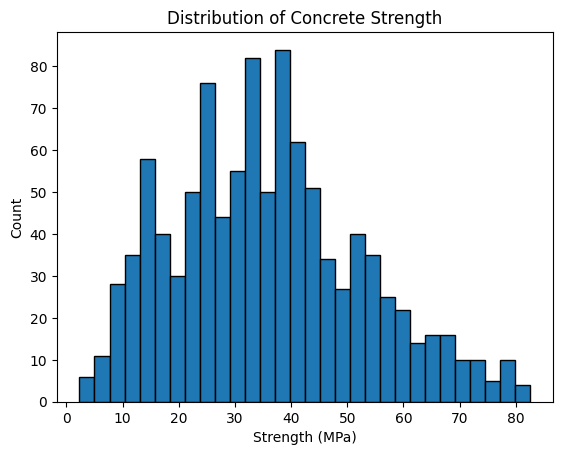

In [22]:
# Plot histogram for the target variable (Concrete Strength)
plt.hist(data['Strength'], bins=30, edgecolor='k')
plt.title('Distribution of Concrete Strength')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()

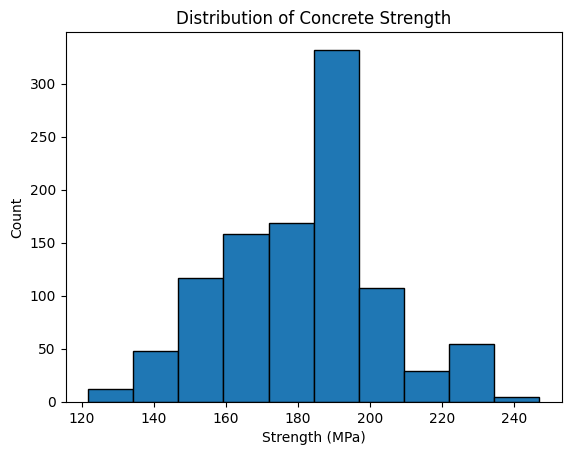

In [23]:
# Plot the histogram
plt.hist(data['Water'], bins=10, edgecolor='k')
plt.title('Distribution of Concrete Strength')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()

Scatterplot example visualization

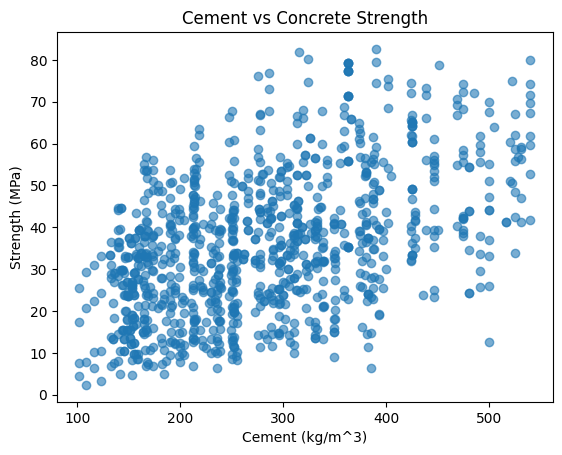

In [24]:
# Scatterplot: Cement vs Concrete Strength
plt.scatter(data['Cement'], data['Strength'], alpha=0.6)
plt.title('Cement vs Concrete Strength')
plt.xlabel('Cement (kg/m^3)')
plt.ylabel('Strength (MPa)')
plt.show()

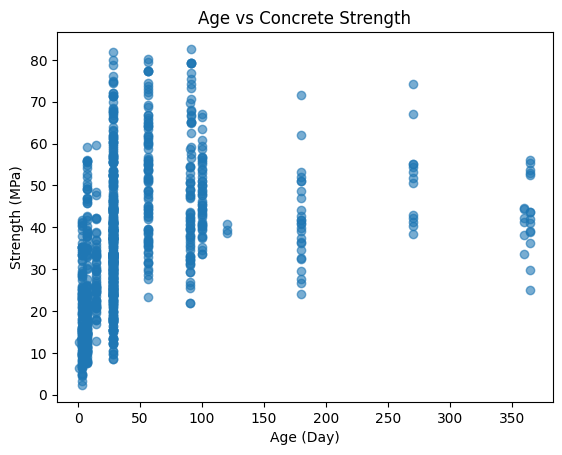

In [25]:
# Scatterplot: Cement vs Concrete Strength
plt.scatter(data['Age'], data['Strength'], alpha=0.6)
plt.title('Age vs Concrete Strength')
plt.xlabel('Age (Day)')
plt.ylabel('Strength (MPa)')
plt.show()

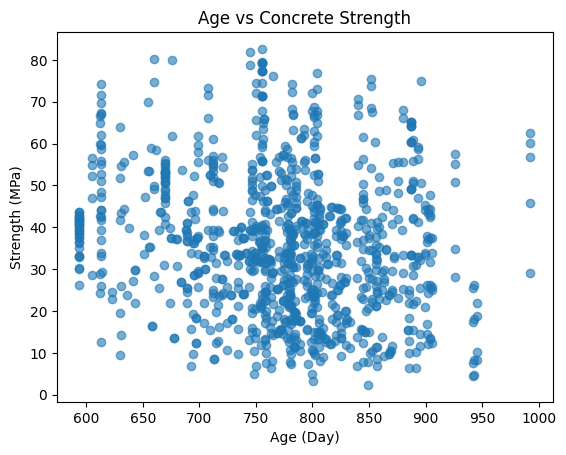

In [26]:
# Scatterplot: Cement vs Concrete Strength
plt.scatter(data['Fine Aggregate'], data['Strength'], alpha=0.6)
plt.title('Age vs Concrete Strength')
plt.xlabel('Age (Day)')
plt.ylabel('Strength (MPa)')
plt.show()

# Transform data and Data Loader

In [27]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data.iloc[:, :-1].values  # First 8 columns
y = data.iloc[:, -1].values.reshape(-1, 1)  # Last column (strength)

# Standardize inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Set seed and shuffle
torch.manual_seed(42)
num_samples = X_tensor.shape[0]
indices = torch.randperm(num_samples)

# 80/20 split
split_idx = int(0.8 * num_samples)
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

# Create splits
X_train = X_tensor[train_idx]
y_train = y_tensor[train_idx]
X_test = X_tensor[test_idx]
y_test = y_tensor[test_idx]

# Print shapes
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 824
Testing samples: 206


# Model Architecture

In [28]:
# Custom MLP class for regression
class ConcreteMLP(nn.Module):
    def __init__(self, input_size=8, hidden_size=16, output_size=1):
        super(ConcreteMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.relu = nn.ReLU()                          # Activation
        self.fc2 = nn.Linear(hidden_size, output_size) # Output layer
    
    def forward(self, x):
        x = self.fc1(x)   # Apply first linear layer
        x = self.relu(x)  # Apply ReLU activation
        x = self.fc2(x)   # Apply output layer
        return x

# Create model instance
model = ConcreteMLP()
print(model)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [34]:
# Step 1: Define the model class
class CustomMLPModel(nn.Module):
    def __init__(self):
        super(CustomMLPModel, self).__init__()
        
        # Define the layers
        self.fc1 = nn.Linear(6, 24)   # Input layer → 24 hidden units
        self.relu1 = nn.ReLU()       # First activation
        self.fc2 = nn.Linear(24, 12) # Second hidden layer
        self.relu2 = nn.ReLU()       # Second activation
        self.fc3 = nn.Linear(12, 1)   # Output layer → 1 unit

    # Step 2: Define the forward pass
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Step 3: Instantiate and print the model
custom_model = CustomMLPModel()
print(custom_model)

CustomMLPModel(
  (fc1): Linear(in_features=6, out_features=24, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=24, out_features=12, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=12, out_features=1, bias=True)
)


# Training Loop

In [37]:
import torch.nn as nn
import torch.optim as optim

# Instantiate the model
model = ConcreteMLP()

# Define the loss function
loss_fn = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(optimizer)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [38]:
# Number of training epochs
num_epochs = 300

# List to store loss values per epoch
train_losses = []

# Training loop
for epoch in range(num_epochs):
    # ===== Forward Pass =====
    y_pred = model(X_train)

    # ===== Compute Loss =====
    loss = loss_fn(y_pred, y_train)

    # ===== Backward Pass =====
    loss.backward()

    # ===== Optimizer Step =====
    optimizer.step()

    # ===== Zero Gradients =====
    optimizer.zero_grad()

    # ===== Record Loss =====
    train_losses.append(loss.item())

    # ===== Print Occasionally =====
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 942.0057
Epoch [100/300], Loss: 227.2621
Epoch [150/300], Loss: 165.6034
Epoch [200/300], Loss: 141.9866
Epoch [250/300], Loss: 125.5820
Epoch [300/300], Loss: 105.3608


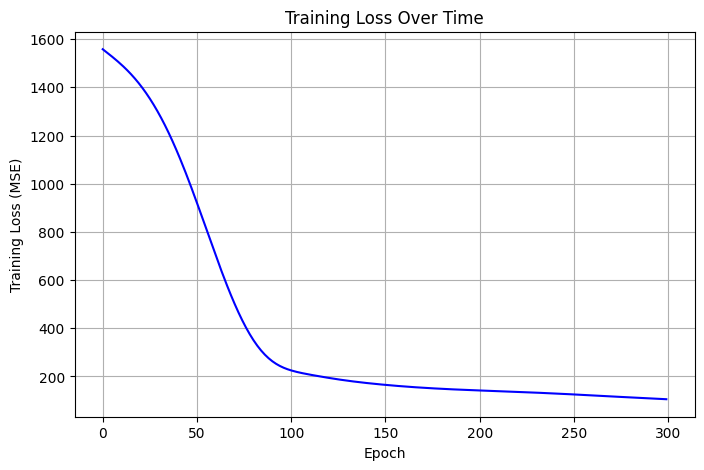

In [39]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_losses, linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

# Evaluation

In [32]:
# Evaluate model performance

with torch.no_grad():
    # Predict on train set
    train_preds = model(X_train)
    train_loss = loss_fn(train_preds, y_train)

    # Predict on test set
    test_preds = model(X_test)
    test_loss = loss_fn(test_preds, y_test)

print(f"Final Training Loss (MSE): {train_loss.item():.4f}")
print(f"Final Testing Loss (MSE): {test_loss.item():.4f}")

Final Training Loss (MSE): 124.5417
Final Testing Loss (MSE): 136.3907


In [33]:
# Calculate RMSE
train_rmse = torch.sqrt(train_loss)
test_rmse = torch.sqrt(test_loss)

print(f"Training RMSE: {train_rmse.item():.2f} MPa")
print(f"Testing RMSE: {test_rmse.item():.2f} MPa")

Training RMSE: 11.16 MPa
Testing RMSE: 11.68 MPa
